In [1]:
import scipy as sp
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum, angle, exp, cos
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa
tau = 6.4*1e-13 # scattering time in seconds
from utils import hbar, c, alpha
euler_gamma = 0.57721 # Euler-Mascheroni constant

### This notebook re-creates some of the figures in the paper "Extraordinary optical reflection from sub-wavelength cylinder arrays" by Gomez-Medina

We note that the normalized (with respect to lattice constant, $D$) reciprocal lattice vectors are given by $K_mD=2\pi m$ and the in-plane scattered wavevectors are therefore given by $q_mD=\sqrt{(2\pi)^2(\omega D/(2\pi c))^2-(Q_0D-2\pi m)^2}$, where $Q_0$ is the in-plane wavevector of the incident field, and $\omega/c$ is the modulus of the free space wavevector. 

In [2]:
def G_b_sum_term(x, m, Q_0_D = 0.8*pi): # x is omega*D/(2pi*c). G_b_sum_term gives one term in the sum given by Equation 7 of the paper
    # Note that we require m > 1 in the below since letting m run over both positive and negative integers will result in double counting
    K_m = 2*pi*m 
    q_m_sqrd = (2*pi)**2*x**2-(Q_0_D-K_m)**2 + 0j # Added a 0j so that we can take square root of negative numbers. 
    q_minus_m_sqrd = (2*pi)**2*x**2-(Q_0_D+K_m)**2 + 0j
    return (1/2)*(1j/sqrt(q_m_sqrd) + 1j/sqrt(q_minus_m_sqrd) - 2/K_m) # Sum term from equation 7
# G_0_sum_term gives one term in the sum given by Equation 5 of the paper (for x=y=0. That is, evaluated at the vertical location of the grating and at a grating site)
def G_0_sum_term(x, m, Q_0_D=0.8*pi): # x is omega*D/(2*pi*c) as in G_b_sum_term
    K_m = 2*pi*m
    q_m_sqrd = (2*pi)**2*x**2-(Q_0_D-K_m)**2 + 0j
    return 1j/(2*sqrt(q_m_sqrd))

### For s-polarization, the quantity $Q_0\times D$ defined in the cell below should be set to $Q_0D=0.8\pi$. 

In [6]:
N = 1000000 # Number of frequency/wavelength points sampled
M = 10 # Number of reciprocal lattice sum terms for G_b
x_v = linspace(0.0001, 2-1e-5, N) # omega*D/(2*pi*c) The subtraction of 1e-5 is so we won't have issues at normal incidence (Q_0_D=0)
Q_0_D_v = np.array([0, 0.2, 0.6, 0.8])*pi # For s-polarization, the paper only considers normal incidence and Q_0_D=0.8*pi (Figure 1 and Figure 2)
G_b_v_v = zeros((len(Q_0_D_v), N), dtype=complex)
for (Q_0_D_idx, Q_0_D) in enumerate(Q_0_D_v):
    print("Q_0_D/pi: ", Q_0_D/pi);
    G_b_v = zeros(N, dtype=complex) 
    for (x_idx, x) in enumerate(x_v):
        G_b = 0
        G_b_zero_term = 1j/(2*sqrt((2*pi)**2*x**2-(Q_0_D)**2 + 0j))
        for m in range(1, M):
            G_b += G_b_sum_term(x, m, Q_0_D=Q_0_D)
        G_b += euler_gamma/(2*pi) # Last term in Equation 7
        G_b += log(x/2)/(2*pi) # Second to last term in Equation 7
        G_b += G_b_zero_term # First term in Equation 7
        G_b += -1j/4 # Second term in Equation 7
        G_b_v[x_idx] = G_b
    G_b_v_v[Q_0_D_idx, :] = G_b_v 

Q_0_D/pi:  0.0
Q_0_D/pi:  0.2
Q_0_D/pi:  0.6
Q_0_D/pi:  0.8


### Below, we calculate the parallel polarizability for the parameters given by the paper

In [7]:
epsilon_minus_one_term = 4/9*x_v**2 # Given by the paper
alpha_zz_inv = (1-1j*(pi/4)*epsilon_minus_one_term)/(pi*epsilon_minus_one_term) # Inverse longitudinal polarizability normalized by light wavevector 

### The plot below is Figure 2(a) of the paper

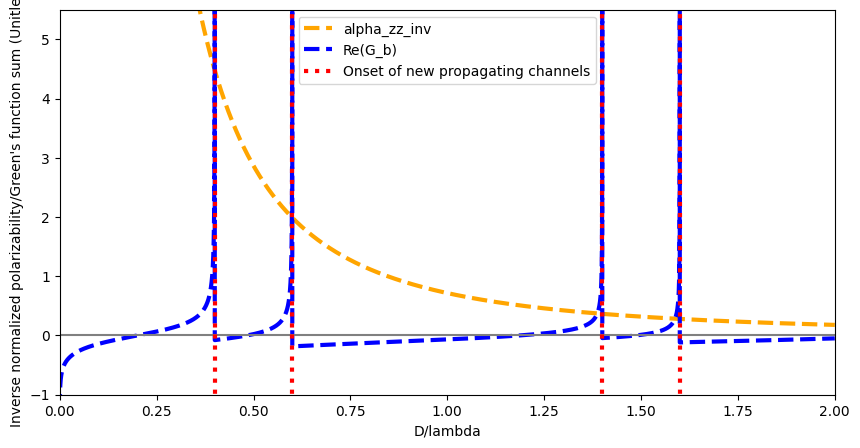

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
Q_0_D_idx = -1
G_b_v = G_b_v_v[Q_0_D_idx]
Q_0_D = Q_0_D_v[Q_0_D_idx]
ax.plot(x_v, alpha_zz_inv.real, linestyle="dashed", color="orange", linewidth=3, label="alpha_zz_inv")
ax.plot(x_v, G_b_v.real, linestyle="dashed", color="blue", linewidth=3, label="Re(G_b)")
ax.hlines([0], 0, 2, color="Grey")
ax.set_ylim(-1, 5.5)
ax.set_xlim(0, 2)
ax.set_xlabel("D/lambda");
ax.set_ylabel("Inverse normalized polarizability/Green's function sum (Unitless)");
for m in range(-3, 3):
    ax.vlines([Q_0_D/(2*pi)-m], -10, 10, color="red", linestyle="dotted", linewidth=3)
    if m==-3:
        ax.vlines([-(Q_0_D/(2*pi))+m], -10, 10, color="red", linestyle="dotted", label="Onset of new propagating channels", linewidth=3)
    ax.vlines([-(Q_0_D/(2*pi))+m], -10, 10, color="red", linestyle="dotted", linewidth=3)
ax.legend();

### Now we find the reflectance, R, (for s-polarization $\mathbf{E}=E\mathbf{e}_z$) through Equation 14

In [15]:
#N = 100000  Keep number of frequency points same as for the lattice green's function sum and polarizability calculation
M = 20 # Number of reciprocal lattice sum terms
#x_v = linspace(0.0001, 2, N) # omega*D/(2*pi*c) Keep range of wavelengths the same as well, obviously
G_0_v_v = zeros((len(Q_0_D_v), N), dtype=complex)
for (Q_0_D_idx, Q_0_D) in enumerate(Q_0_D_v):
    Q_0_D = Q_0_D_v[Q_0_D_idx]
    print("Q_0_D/pi: ", Q_0_D/pi);
    G_0_v = zeros(N, dtype=complex)
    for (x_idx, x) in enumerate(x_v):
        G_0 = 0
        for m in range(-M, M):
            G_0 += G_0_sum_term(x, m, Q_0_D=Q_0_D)
        G_0_v[x_idx] = G_0
    G_0_v_v[Q_0_D_idx, :] = G_0_v

Q_0_D/pi:  0.0
Q_0_D/pi:  0.2
Q_0_D/pi:  0.6
Q_0_D/pi:  0.8


In [46]:
R_v_v = zeros((len(Q_0_D_v), N ), dtype=complex)
for Q_0_D_idx in range(0, len(Q_0_D_v)):
    Q_0_D = Q_0_D_v[Q_0_D_idx]
    G_0_v = G_0_v_v[Q_0_D_idx, :]
    G_b_v = G_b_v_v[Q_0_D_idx, :]
    G_0_v_imag = G_0_v.imag
    R_term_2 = ((alpha_zz_inv - G_b_v).real)**2 + (G_0_v_imag)**2
    R_term_1 = G_0_v_imag/(2*sqrt((2*pi)**2*x_v**2-(Q_0_D)**2 + 0j))
    R_v = R_term_1/R_term_2
    R_v_v[Q_0_D_idx, :] = R_v

### The figure below is Figure 2(b) of the paper. Note that below a certain value of $D/\lambda$, the quantity $q_0$ will be imaginary. Below this threshold, the reflectance has no physical meaning since the incident wave would be evanescent away from the array.

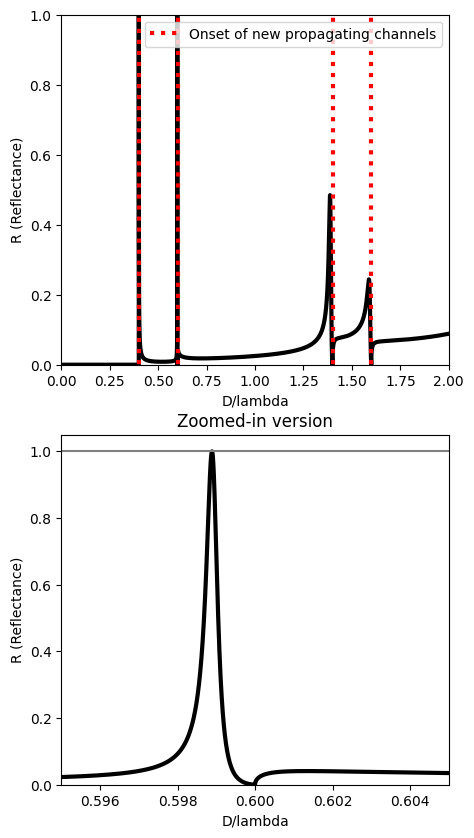

In [47]:
Q_0_D_idx = -1
Q_0_D = Q_0_D_v[Q_0_D_idx]
R_v = R_v_v[Q_0_D_idx, :]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 10))
ax1.plot(x_v, R_v.real, linewidth=3, color="black")
ax1.set_ylim(0, 1.001);
ax1.set_xlim(0, 2);
ax1.set_ylabel("R (Reflectance)")
ax1.set_xlabel("D/lambda");

for m in range(-3, 3):
    ax1.vlines([Q_0_D/(2*pi)-m], -10, 10, color="red", linestyle="dotted", linewidth=3)
    if m==-3:
        ax1.vlines([-(Q_0_D/(2*pi))+m], -10, 10, color="red", linestyle="dotted", label="Onset of new propagating channels", linewidth=3)
    ax1.vlines([-(Q_0_D/(2*pi))+m], -10, 10, color="red", linestyle="dotted", linewidth=3)
ax1.legend();
ax2.plot(x_v, R_v.real, linewidth=3, color="black")
ax2.set_ylim(0, 1.05);
ax2.set_xlim(0.595, 0.605);
ax2.set_ylabel("R (Reflectance)")
ax2.set_xlabel("D/lambda");
ax2.set_title("Zoomed-in version");
ax2.hlines([1], 0, 1, color="Gray");

In [48]:
print("Maximum reflectance for s polarization: ", R_v.real.max())
print("Reflection at D/lambda=2: ", R_v.real[-1])

Maximum reflectance for s polarization:  0.9999961058967975
Reflection at D/lambda=2:  0.0886402569703446


### The figure below is the inset of Figure 1a for normal incidence (s-polarization)

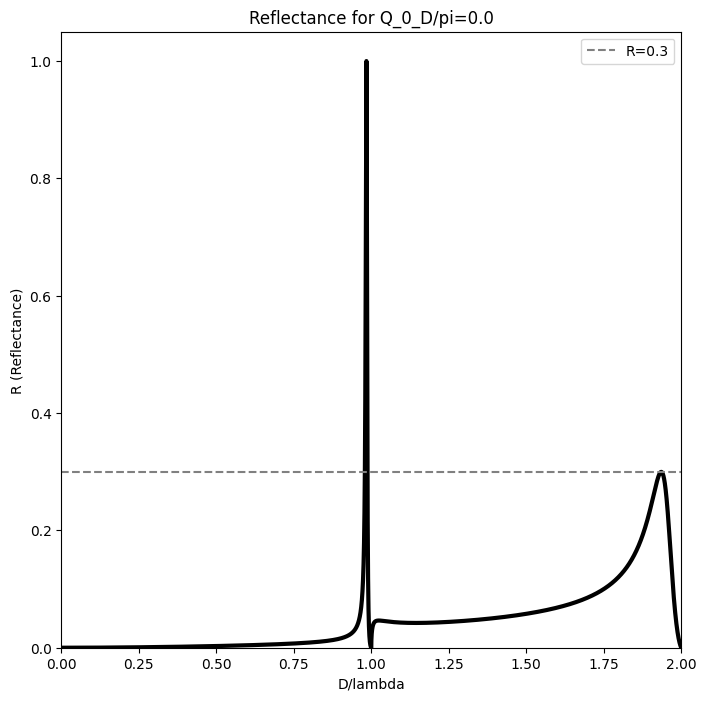

In [60]:
Q_0_D_idx = 0
Q_0_D = Q_0_D_v[Q_0_D_idx]
R_v = R_v_v[Q_0_D_idx]
fig, ax1 = plt.subplots(figsize=(8, 8))
ax1.plot(x_v, R_v.real, linewidth=3, color="black")
ax1.set_ylim(0, 1.05);
ax1.set_xlim(0, 2);
ax1.hlines([0.3], 0, 2, color="Gray", linestyle="dashed", label="R=0.3")
ax1.legend()
ax1.set_ylabel("R (Reflectance)")
ax1.set_xlabel("D/lambda");
ax1.set_title(f"Reflectance for Q_0_D/pi={Q_0_D/pi}");

In [61]:
print("Maximum reflectance for s polarization: ", R_v.real.max())
print("Reflection at D/lambda=2: ", R_v.real[-1])

Maximum reflectance for s polarization:  0.9999999515993873
Reflection at D/lambda=2:  8.470805053973713e-06


### P-polarized light (Figure 3)
In this case, we have to deal with the in-plane bare polarizabilities, given by Equation 17, which we reiterate below:
$k^2\alpha_{xx}=k^2\alpha_{yy}\approx (2\pi (ka)^2)\frac{\varepsilon-1}{\varepsilon+1}\Big[1-i\frac{\pi}{4}(ka)^2\frac{\varepsilon-1}{\varepsilon+1} \Big]^{-1}$ with $(\varepsilon-1)/(\varepsilon+1)=\frac{8}{9}\frac{D^2}{(2\pi a)^2}$ in the paper. 

Thus we obtain $k^2\alpha_{xx}=k^2\alpha_{yy}\approx \frac{8}{9}\Big[2\pi \frac{(kD)^2}{(2\pi)^2}\Big]\Big[1-i\frac{\pi}{4}\frac{8}{9}\frac{(kD)^2}{(2\pi)^2} \Big]^{-1} = \frac{8}{9}\Big[2\pi x^2 \Big]\Big[1-\frac{i2\pi}{8}\frac{8}{9} x^2 \Big]^{-1}$ (with x defined as in the functions G_b_sum_term

In [94]:
# bare polarizabilities
#N = 10000
#x_v = linspace(0.0001, 2, N) # omega*D/(2*pi*c)
x_term = (2*pi)*(8/9)*(x_v**2)
#x_term = (2*pi)*(9/9)*(x_v**2)
alpha_xx_inv = alpha_yy_inv = (1 - 1j*x_term/8)/x_term

In [95]:
def g_yy_sum_term(x, m, Q_0_D = 0.2*pi):
    K_m = m/x # K_m divided by k: 2*pi*m*c/(D*omega)
    Q_0 = (Q_0_D/x)/(2*pi) # Q_0 divided by k
    q_m = sqrt(1-(Q_0-K_m)**2 + 0j)
    q_minus_m = sqrt(1-(Q_0+K_m)**2 + 0j)

    prefac = 1/(4*pi*x)
    term_1 = 1j*q_m
    term_2 = 1j*q_minus_m
    term_3 = 2*K_m
    term_4 = 1/K_m
    return -prefac*(term_1 + term_2 + term_3 - term_4)

def g_xx_sum_term(x, m, Q_0_D = 0.2*pi):
    K_m = m/x # K_m divided by k: 2*pi*m*c/(D*omega)
    Q_0 = (Q_0_D/x)/(2*pi) # Q_0 divided by k
    q_m = sqrt(1-(Q_0-K_m)**2 + 0j)
    q_minus_m = sqrt(1-(Q_0+K_m)**2 + 0j)

    prefac = 1/(4*pi*x)
    term_1 = 1j*(K_m-Q_0)**2/q_m
    term_2 = 1j*(K_m+Q_0)**2/q_minus_m
    term_3 = 2*K_m
    term_4 = 1/K_m
    return -prefac*(term_1 + term_2 - term_3 - term_4)

def return_R_term(m, x, alpha_xx, alpha_yy, Q_0_D = 0.2*pi):
    K_m = m/x # K_m divided by k: 2*pi*m*c/(D*omega)
    Q_0 = (Q_0_D/x)/(2*pi) # Q_0 divided by k
    q_m_sqrd = 1-(Q_0-K_m)**2 
    q_0_sqrd = 1-Q_0**2
    if q_m_sqrd < 0: 
        return 0
    q_m = sqrt(q_m_sqrd + 0j)
    q_0 = sqrt(q_0_sqrd + 0j)
    f_m = alpha_yy*Q_0*(Q_0-K_m) - alpha_xx*q_0*q_m
    prefac = 1/(2*pi*x)**2/(4*q_m*q_0)
    return prefac * np.abs(f_m)**2

In [96]:
M = 10
#x_v = linspace(0.0001, 2, N) # omega*D/(2*pi*c) Make sure this is consistent across all calculations
G_yy_v = zeros(N, dtype=complex) 
G_xx_v = zeros(N, dtype=complex) 
#Q_0_D = 0.8*pi
#Q_0_D = 0.6*pi
for (x_idx, x) in enumerate(x_v):
    Q_0 = (Q_0_D/x)/(2*pi) # Q_0 divided by k
    q_0_sqrd = 1-Q_0**2
    q_0 = sqrt(q_0_sqrd + 0j)
    prefac = 1/(4*pi*x)
    G_yy = 0
    G_xx = 0
    #G_xx += -1/(4*pi)*(log(x/2) + euler_gamma - 1/2)
    G_xx += -1/(4*pi)*(log(x/2) + euler_gamma + 1/2)
    G_xx += (1/6)*(pi/x**2)*(1/(2*pi))**2
    #G_xx += (1/3)*(pi/x**2)*(1/(2*pi))**2
    G_xx += 1j*(1/8-prefac*Q_0**2/q_0)

    #G_yy += -1/(4*pi)*(log(x/2) + euler_gamma + 1/2)
    G_yy += -1/(4*pi)*(log(x/2) + euler_gamma - 1/2)
    G_yy += -(1/6)*(pi/x**2)*(1/(2*pi))**2 # Note, the different versions of this paper have this with a minus or a plus sign
    #G_yy += -(1/3)*(pi/x**2)*(1/(2*pi))**2 # Note, the different versions of this paper have this with a minus or a plus sign

    G_yy += 1j*(1/8-prefac*q_0**2/q_0)
    for m in range(1, M):
        G_xx += g_xx_sum_term(x, m, Q_0_D=Q_0_D)
        G_yy += g_yy_sum_term(x, m, Q_0_D=Q_0_D)
    G_xx_v[x_idx] = G_xx
    G_yy_v[x_idx] = G_yy
alpha_xx_bare = 1/alpha_xx_inv
alpha_yy_bare = 1/alpha_yy_inv
alpha_xx_renormalized = alpha_xx_bare/(1 + G_yy_v*alpha_xx_bare)
alpha_yy_renormalized = alpha_yy_bare/(1 + G_xx_v*alpha_yy_bare)

### Verifying $G_b = -(\partial_{xx} G_b + \partial_{yy} G_b)/k^2$. Note that the code below is for $Q_0/D=0.8\pi$. We change this for the figures after. 

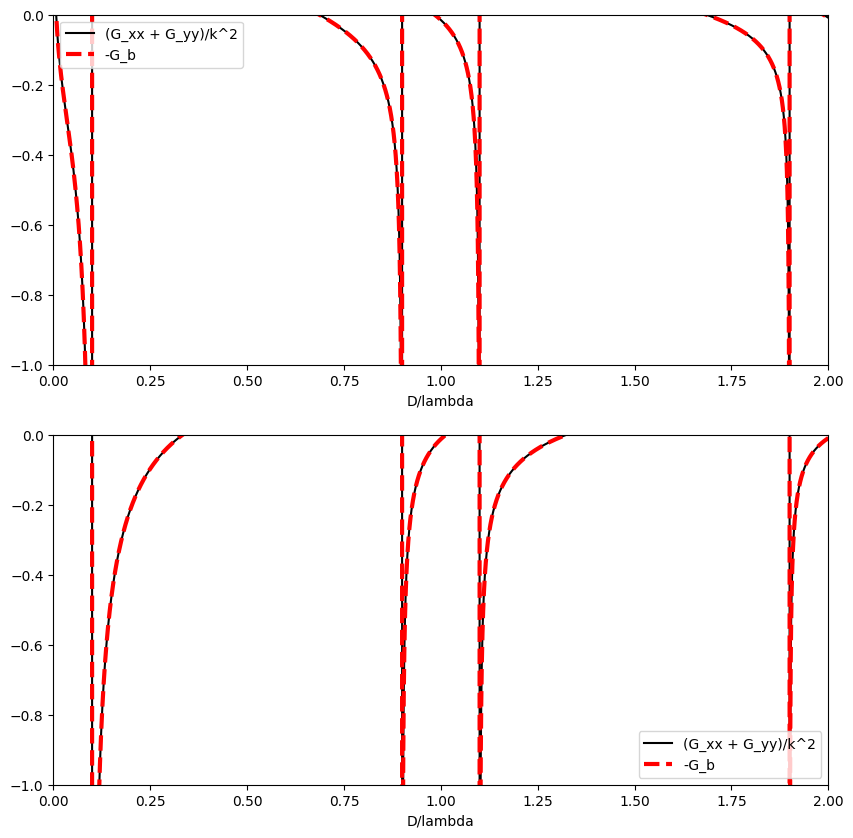

In [97]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
ax1.plot(x_v, (G_xx_v + G_yy_v).real, label="(G_xx + G_yy)/k^2", color="black")
ax1.plot(x_v, -G_b_v.real, linestyle="dashed", label="-G_b", linewidth=3, color="red")
ax1.set_ylim(-1, 0);

ax2.plot(x_v, (G_xx_v + G_yy_v).imag, color="black", label="(G_xx + G_yy)/k^2")
ax2.plot(x_v, -G_b_v.imag, linestyle="dashed", label="-G_b", linewidth=3, color="red")
ax2.set_ylim(-1, 0)
ax1.set_xlim(0, 2)
ax2.set_xlim(0, 2);
ax1.set_xlabel("D/lambda")
ax2.set_xlabel("D/lambda")
ax2.legend();
ax1.legend();

### We now also check that the Green's function sum may be obtained in real space

In [98]:
# Green's function second partial derivative divided by D squared 
def one_term_cylinder_yy(n, lambda_, Q_0_D=Q_0_D): # lambda_ is lambda divided by D
    kr = (2*pi/lambda_)*n
    coeff = -(1j/4)*(2*pi/np.abs(n))/lambda_
    return coeff * exp(1j*Q_0_D*n) * hankel1(1, np.abs(kr))
    #return 2 * coeff  * cos(Q_0_D*n) * hankel1(1, kr)

In [99]:
M = 20
#N_prime = 1000000
#x_v_prime = linspace(0.0001, 2, N_prime) # omega*D/(2*pi*c)
x_v_prime = x_v
G_yy_real_space_v = zeros(N_prime, dtype=complex)
for (x_idx, x) in enumerate(x_v_prime): # x is D/lambda
    G_yy_real_space = 0
    for m in range(-M, M):
        if m==0:
            continue
        G_yy_real_space += 1/((2*pi*x)**2)*one_term_cylinder_yy(m, 1/x, Q_0_D=Q_0_D)
    G_yy_real_space_v[x_idx] = G_yy_real_space

In [63]:
Q_0_D/pi

0.0

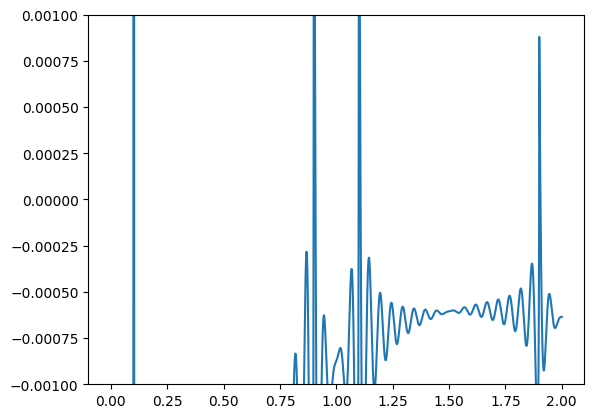

In [115]:
#plt.plot(x_v_prime, G_yy_real_space_v.imag)
#plt.plot(x_v, G_yy_v.imag);
#plt.plot(x_v_prime, -G_b_v.real -G_yy_real_space_v.real, color="black")
#plt.plot(x_v, G_yy_real_space_v.real)
#plt.plot(x_v, G_yy_v.real)
#plt.plot(x_v, (x_v**2)*(G_yy_real_space_v.real-G_yy_v.real))
plt.plot(x_v, (G_yy_real_space_v.real-G_yy_v.real))

plt.ylim(-0.001, 0.001);
#plt.ylim(-1, 0.5);

In [101]:
alpha_xx_bare = 1/alpha_xx_inv
alpha_yy_bare = 1/alpha_yy_inv
alpha_xx_renormalized_real_space = alpha_xx_bare/(1 + G_yy_real_space_v*alpha_xx_bare)
alpha_yy_renormalized_real_space = alpha_yy_bare/(1 - (G_b_v + G_yy_real_space_v)*alpha_yy_bare)

In [111]:
M = 2
R_v_p_polarization = zeros(N, dtype=complex) 
for (x_idx, x) in enumerate(x_v):
    R = 0
    for m in range(-M, M):
        #R += return_R_term(m, x, alpha_xx_renormalized[x_idx], alpha_yy_renormalized[x_idx], Q_0_D = Q_0_D) # From reciprocal space sum (like paper)
        R += return_R_term(m, x, alpha_xx_renormalized_real_space[x_idx], alpha_yy_renormalized_real_space[x_idx], Q_0_D = Q_0_D) # From real space sum
    R_v_p_polarization[x_idx] = R

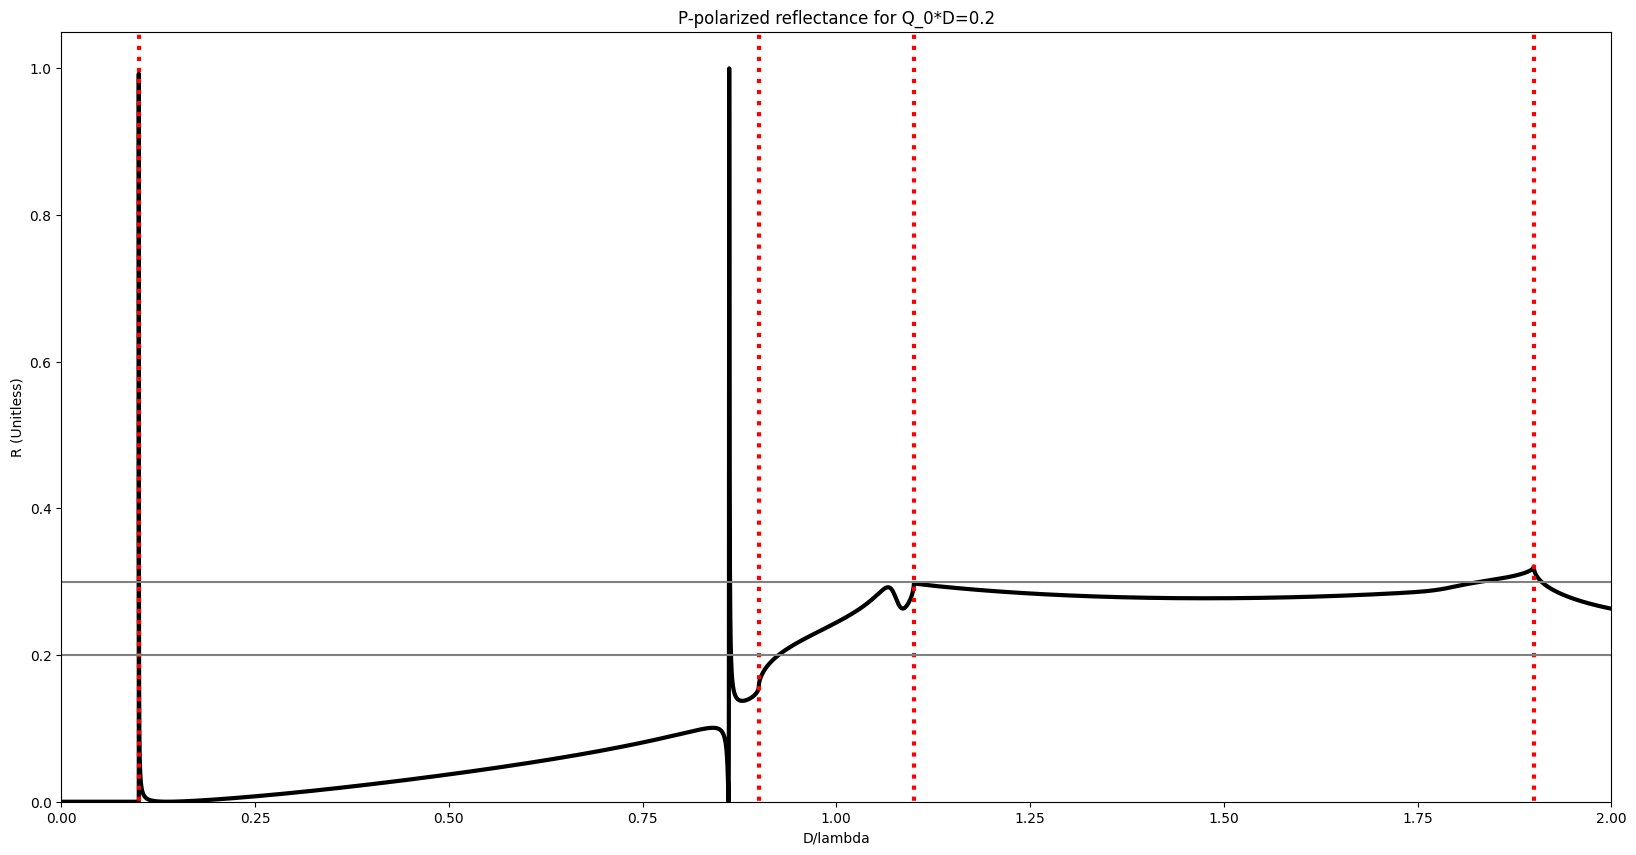

In [104]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(x_v, R_v_p_polarization, color="black", linewidth=3)
ax.set_xlim(0, 2);
ax.set_ylim(0, 1.05);
for m in range(-3, 3):
    ax.vlines([Q_0_D/(2*pi)-m], -10, 10, color="red", linestyle="dotted", linewidth=3)
    if m==-3:
        ax.vlines([-(Q_0_D/(2*pi))+m], -10, 10, color="red", linestyle="dotted", label="Onset of new propagating channels", linewidth=3)
    ax.vlines([-(Q_0_D/(2*pi))+m], -10, 10, color="red", linestyle="dotted", linewidth=3)
ax.hlines([0.3], 0, 2, label="R=0.3", color="Grey")
ax.hlines([0.2], 0, 2, label="R=0.3", color="Grey");
ax.set_title(f"P-polarized reflectance for Q_0*D={Q_0_D/pi}");
ax.set_ylabel("R (Unitless)");
ax.set_xlabel("D/lambda");

In [105]:
print("Maximum reflectance for s polarization: ", R_v_p_polarization.real.max())
print("Reflection at D/lambda=2: ", R_v_p_polarization.real[-1])

Maximum reflectance for s polarization:  0.9999907604931465
Reflection at D/lambda=2:  0.26323777392293196


From the paper, we see that (taking two derivatives of Equation 5): 

$\begin{align*} 
\partial^2_{y}G(\mathbf{r})=-\sum_{m=-\infty}^\infty \frac{i q_m}{2D} = -\Bigg[\sum_{m=1}^\infty \frac{iq_m}{2D}+\frac{iq_{-m}}{2D}\Bigg]-\frac{iq_0^2}{2Dq_0}
\end{align*}$

Similarly, we see that: 

$\begin{align*}
\partial_x^2 G(\mathbf{r})=-\sum_{m=-\infty}^\infty \frac{i(Q_0-K_m)^2}{2Dq_m} = -\Bigg[\sum_{m=1}^\infty \frac{i(Q_0-K_m)^2}{2Dq_m} + \frac{i(Q_0+K_m)^2}{2Dq_{-m}}\Bigg] - \frac{iQ_0^2}{2Dq_0}
\end{align*}$

### $H_{\text{scattered}}=-\frac{iH_0}{D}\sum_{m=-\infty}^\infty \Big(\alpha_{yy}Q_0\partial_x + \alpha_{xx}q_0\partial_y\Big)e^{i(Q_0-K_m)x}\frac{i}{2q_m}e^{iq_m|y|}$

### $H_{\text{scattered}}=\frac{H_0}{D}\sum_{m=-\infty}^\infty \Big(\alpha_{yy}Q_0(Q_0-K_m) + \alpha_{xx}q_0q_m\Big)e^{i(Q_0-K_m)x}\frac{i}{2q_m}e^{iq_m|y|}$